We illustrate the idea using a delayed transcription-splicing model. The full model is
$$
D_0 \xleftrightharpoons[\sigma_\text{on}]{\sigma_\text{off}} D_1, 
\qquad 
D_1 \xrightarrow{\rho} D_1+U,
\qquad
U \xRightarrow{\tau} S,
\qquad
S \xrightarrow{d} \varnothing .
$$
Here the gene switches between an inactive state $D_0$ and an active state $D_1$ with rates $\sigma_\text{off}$ and $\sigma_\text{on}$, respectively. When the gene is active, unspliced transcripts $U$ are produced at rate $\rho$. Each unspliced transcript is converted into a spliced transcript $S$ after a fixed processing delay $\tau$, and spliced transcripts are degraded with first-order rate $d$. The corresponding reduced model retains only the transcriptional dynamics of unspliced RNA,
$$
D_0 \xleftrightharpoons[\sigma_\text{on}]{\sigma_\text{off}} D_1, 
\qquad 
D_1 \xrightarrow{\rho} D_1+U,
\qquad
U \xRightarrow{\tau} \varnothing .
$$
The full model is then parametrized by $\varphi_\text{f}=\{\rho,\sigma_\text{on},\sigma_\text{off},d\}$, whereas the reduced model is parametrized by $\varphi_\text{r}=\{\rho,\sigma_\text{on},\sigma_\text{off}\}$. The additional parameter in the full model is therefore the spliced-RNA degradation rate $d$.

# A quick demo for applying BRIDGE to a delayed transcription-splicing model

![illustrate](https://github.com/X-Y-Zhou/BRIDGE_analysis/blob/main/illustrate.png)

In [16]:
# Import packages
using Optim, Statistics, Distributions, Plots,StatsBase,DelimitedFiles,Random
using FastGaussQuadrature,Flux,DataFrames,CSV,HypergeometricFunctions

In [2]:
# Define Reduced model PGF
function G_tele_delay(σon,σoff,ρ,τ,z)
    u1 = z-1
    r = 1-ρ*u1+σoff+σon
    θ = sqrt(Complex((ρ*u1-σoff-σon)^2+4*ρ*σon*u1))
    uz = (r+θ-1)/2
    uf = (r-θ-1)/2
    G1 = (uz*exp(-uf*τ)-uf*exp(-uz*τ))/θ + ρ*u1*σon*(exp(-uf*τ)-exp(-uz*τ))/(θ*(σoff+σon))
    return real(G1)
end

G_tele_delay (generic function with 1 method)

In [3]:
# Define the function to compute Full model PGF with BRIDGE
function BRIGE_forward(input,ϕf_r,p,re)
    input = vcat(input,ϕf_r)
    output = re(p)(input)
    return output
end

function BRIDGE_compute_full(ps,params,re)
    σon,σoff,ρ = ps[1:3]
    ϕf_r = ps[4:end]
    input = G_tele_delay.(σon,σoff,ρ,1,z1)
    output = BRIGE_forward(input,ϕf_r,params,re)
    return vec(output)
end

BRIDGE_compute_full (generic function with 1 method)

In [4]:
# Define objective function
function int_dist(ps, SSA_PGF, a, W, params, re)
    dist = BRIDGE_compute_full(ps,params,re).^(1+a) .- BRIDGE_compute_full(ps,params,re).^a .* SSA_PGF .* (1+1/a) .+ SSA_PGF / a
    return sum(W .* dist)
end

int_dist (generic function with 1 method)

In [9]:
# Convert 2d distribution to PGF
function hist_gf2d(hist_data,z1,z2)
    Nx = size(hist_data,1)
    Ny = size(hist_data,2)
    z1_vec = [z1.^i for i = 0 : Nx-1]
    z2_vec = [z2.^i for i = 0 : Ny-1]
    z_mat = z1_vec*z2_vec'
    return sum(z_mat.*hist_data)
end

hist_gf2d (generic function with 1 method)

In [10]:
# Define Gaussian Quadrature points and corresponding weights
n = 7
a,b = [0,1]
interval_X, weights = gausslegendre(n)
x = ((b - a) .* interval_X .+ b .+ a) ./ 2
w = weights * (b - a) / 2

z1 = x
z2 = x

W = vec(w*w');

In [11]:
# Define hidden channels
hidden_channels = 40

# Initialize BRIGE model
model = Chain(Dense(length(z1)+1, hidden_channels,tanh),Dense(hidden_channels, length(z1)*length(z2)),x -> softplus.(x))
params, re = Flux.destructure(model);
ps = Flux.params(params);

In [12]:
# Read trained parameters
using CSV,DataFrames
df = CSV.read("parameters_trained/params_trained2d.txt",DataFrame)
params = df.params
ps = Flux.params(params);

In [13]:
# Read inference counts data
# True value is [σ_on,σ_off,ρ,d] =  [0.595,7.335,37.865,0.474]. You can replace it with your own data.
SSA_counts = readdlm("dataset/synthetic_data/counts_example2d.txt")
N_sample = Int.(SSA_counts[:,1])
M_sample = Int.(SSA_counts[:,2])
Sample_size = length(N_sample)

# Convert counts data to joint distribution
NM_sample = [[N_sample[i],M_sample[i]] for i=1:Sample_size]
N_max = Int(maximum([n for (n, m) in NM_sample]))
M_max = Int(maximum([m for (n, m) in NM_sample]))

joint_prob_matrix = zeros(Float64, N_max+1, M_max+1)
for (m, n) in NM_sample
    joint_prob_matrix[m+1, n+1] += 1
end

joint_prob_matrix /= length(NM_sample)

# Convert joint distribution to PGF
SSA_PGF = vec(hist_gf2d(joint_prob_matrix,z1,z2)');

In [14]:
# Infer parameters
init = [1,1,1,1]
init_ps = log.(init)
itera = 1000
results, time, _,_ = @timed Optim.optimize(ps->int_dist(exp.(ps),SSA_PGF,1.0,W,params,re),init_ps,
Optim.Options(show_trace=true,g_tol=1e-11,iterations = itera)).minimizer

┌ Warning: Layer with Float32 parameters got Float64 input.
│   The input will be converted, but any earlier layers may be very slow.
│   layer = Dense(8 => 40, tanh)
│   summary(x) = 8-element Vector{Float64}
└ @ Flux /Users/x-y-zhou/.julia/packages/Flux/n3cOc/src/layers/stateless.jl:60


Iter     Function value    √(Σ(yᵢ-ȳ)²)/n 
------   --------------    --------------
     0     3.373610e-01     3.577696e-03
 * time: 0.048573970794677734
     1     3.373610e-01     4.222718e-03
 * time: 0.678969144821167
     2     3.338366e-01     5.369547e-03
 * time: 0.6882679462432861
     3     3.271259e-01     6.523269e-03
 * time: 0.6886270046234131
     4     3.219455e-01     7.724912e-03
 * time: 0.6889550685882568
     5     3.160874e-01     9.437087e-03
 * time: 0.6892349720001221
     6     3.062361e-01     1.158482e-02
 * time: 0.6895480155944824
     7     2.946583e-01     1.377799e-02
 * time: 0.6898839473724365
     8     2.842326e-01     1.646364e-02
 * time: 0.6902170181274414
     9     2.690628e-01     1.961596e-02
 * time: 0.6905410289764404
    10     2.502162e-01     2.292287e-02
 * time: 0.6909019947052002
    11     2.311410e-01     2.635827e-02
 * time: 0.6914300918579102
    12     2.101474e-01     2.914053e-02
 * time: 0.6918489933013916
    13     1.8620

(value = [-0.5137480545196922, 2.052863721740311, 3.685328648342053, -0.7390623434621705], time = 6.211163413, bytes = 1086751728, gctime = 0.242644052, gcstats = Base.GC_Diff(1086751728, 80, 15, 18883035, 7748, 164, 242644052, 6, 0))

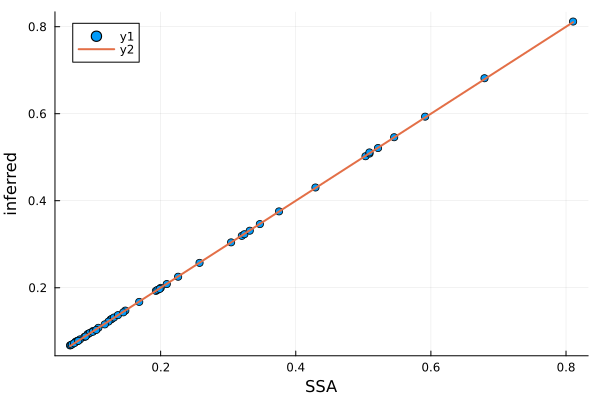

In [15]:
# Obtain inferred Parameters
inferred_params = exp.(results)

# Check inferred Parameters
inferred_PGF = BRIDGE_compute_full(inferred_params,params,re)
scatter(SSA_PGF,inferred_PGF,xlabel="SSA",ylabel="inferred");
plot!([minimum(SSA_PGF),maximum(SSA_PGF)],[minimum(SSA_PGF),maximum(SSA_PGF)],lw=2)